# Core regression: daytime LST on night-time lights

**Specification.** `lst_day_mean ~ ntl_harm` (as `log1p`), instrumented by
`mine_count_20km`, pixel and country x year fixed effects:

```
lst_day_mean ~ 1 | pixel_id + GID_0^year | (log1p(ntl_harm) ~ mine_count_20km)
```

**Engine.** `duckreg` (compressed OLS/2SLS) on the **full** 10 km panel -- every
non-null `lst_day_mean` pixel-year, ~25 M rows, no sampling. `duckreg` groups
duplicate (rounded outcome, rounded regressor, FE) strata before fitting, so the
whole panel fits on a laptop; SEs are cluster-robust (country).

**Runtime.** A two-way-FE fit (`pixel_id + GID_0^year`) on the full panel is
~2-3 min. Section 1 is ~10 min; the Section 2 robustness battery is ~1 h. The
derived panel parquet is built once and cached (`data/_regression_panel_10km.parquet`,
~0.5 GB), and `duckreg` caches its compressed strata under `data/.duckreg/`.

**Contents.** 1 main table (pooled, +pixel FE, TWFE, 2SLS) + first stage /
reduced form. 2 robustness, one data quirk per block: R1 NTL functional form,
R2 DMSP->VIIRS break, R3 gas flares, R4 valid-count filter, R5 alternative
outcomes (night LST, GLASS air temp) / NTL measures (VIIRS median), R6 instrument
radius + price-shock, R7 inference, R8 alternative instrument (political
favoritism `reg_fav`).

Each table is paired with a dot-and-whisker **coefficient plot** (via `src.viz`;
`viz.from_duckreg` adapts a `duckreg` fit).

The spatial companion (one map per assembled column) is
`descriptive_overview.ipynb`; the univariate / bivariate descriptives are in
`descriptive_statistics.ipynb`.

In [1]:
import sys, os, time
import numpy as np
import pandas as pd
import duckdb
import matplotlib.pyplot as plt

import src.viz as viz   # coefficient plots; viz.from_duckreg adapts duckreg fits

# duckreg is a source checkout, not pip-installed -- add it to the path.
DUCKREG_PATH = "/Users/felixschulz/Library/CloudStorage/OneDrive-Personal/Dokumente/Job/UNI/Basel/Research/duckreg"
if DUCKREG_PATH not in sys.path:
    sys.path.insert(0, DUCKREG_PATH)
from duckreg import duckreg

# --- silence DuckDB's per-query progress-bar widget -------------------------
# duckreg (and each duckreg fit) opens its own connections, so patch the
# connection-init hook rather than pass an unsupported kwarg.
try:
    duckdb.default_connection().execute("SET enable_progress_bar = false")
except Exception:
    pass
import duckreg.estimators.base as _dre_base
_dre_orig_init = _dre_base.DuckEstimator._init_connection
def _dre_quiet_init(self):
    _dre_orig_init(self)
    try:
        self.conn.execute("SET enable_progress_bar = false")
    except Exception:
        pass
_dre_base.DuckEstimator._init_connection = _dre_quiet_init

PROJECT = "/Users/felixschulz/Library/CloudStorage/OneDrive-Personal/Dokumente/Job/UNI/Basel/Research/growth-and-temperature"
GRID = "10km"
SRC   = f"{PROJECT}/data/assembled/grid={GRID}/shake=base/ix=*/iy=*/*.parquet"
PANEL = f"{PROJECT}/data/_regression_panel_{GRID}.parquet"   # derived cache, built below

NTL_HI    = 7      # extensive / intensive NTL threshold
VALID_MIN = 300    # min annual valid daytime-LST obs to keep a pixel-year

Y    = "lst_day_mean"
FE   = "pixel_id + GID_0^year"        # TWFE: pixel + country x year
CL   = {"CRV1": "GID_0"}              # cluster by country
XLOG = "log_ntl"                      # = log1p(ntl_harm), precomputed in PANEL
Z    = "mine_count_20km"
# compression=5 rounds continuous strata to 5 sig-figs before grouping (the
# src.analysis production default) -- ~5x faster demeaning, estimates unchanged
# to 3 decimals vs exact compression.
DR   = dict(fitter="auto", compression=5, threads=8, memory_limit="24GB")

In [2]:
# Build the derived regression panel once: the columns the notebook touches plus
# every transform, non-null outcome only, one flat zstd parquet. `union_by_name`
# guards against the per-part schema drift in the assembled mirror.
if not os.path.exists(PANEL):
    con = duckdb.connect()
    con.execute("PRAGMA threads=8")
    con.execute("SET enable_progress_bar = false")
    t = time.time()
    con.execute(f"""
        COPY (
          SELECT pixel_id, year, GID_0, GID_1,
            lst_day_mean, lst_night_mean, glass_ta_mean,
            ntl_harm, viirs_annual_median AS viirs,
            mine_count_10km, mine_count_20km, mine_count_50km, mine_priceshock_20km,
            valid_month_count_day_annual AS valid_day, flare_band, reg_fav,
            ln(ntl_harm + 1.0)                                    AS log_ntl,
            asinh(ntl_harm)                                       AS asinh_ntl,
            (ntl_harm >= {NTL_HI})::INT                           AS lit7,
            CASE WHEN ntl_harm >= {NTL_HI} THEN ln(ntl_harm) END  AS log_ntl_int,
            ln(greatest(viirs, 0) + 1.0)                          AS log_viirs,
            CASE WHEN year <= 2012 THEN 'dmsp'
                 WHEN year  = 2013 THEN 'overlap' ELSE 'viirs' END AS era,
            (coalesce(flare_band, 0) > 0)::INT                    AS is_flare
          FROM read_parquet('{SRC}', union_by_name = true, hive_partitioning = true)
          WHERE lst_day_mean IS NOT NULL
        ) TO '{PANEL}' (FORMAT parquet, COMPRESSION zstd)
    """)
    print(f"built {PANEL} in {time.time()-t:.0f}s ({os.path.getsize(PANEL)/1e6:.0f} MB)")
    con.close()

n, npix, ncty, y0, y1 = duckdb.sql(
    f"SELECT count(*), count(DISTINCT pixel_id), count(DISTINCT GID_0), min(year), max(year) "
    f"FROM read_parquet('{PANEL}')"
).fetchone()
print(f"panel: {n:,} pixel-years | {npix:,} pixels | {ncty} countries | {y0}-{y1}")

panel: 25,268,290 pixel-years | 1,205,166 pixels | 253 countries | 2002-2022


In [3]:
def fit(fml, se=CL, subset=None, data=PANEL):
    """duckreg with the notebook defaults (full panel, cluster by country)."""
    return duckreg(fml, data=data, se_method=se, subset=subset, **DR)

def row(m, term):
    """One coefficient row from a fitted model as a dict."""
    td = m.tidy().set_index("variable")
    if term not in td.index:                       # IV endog term is renamed by duckreg
        term = next((i for i in td.index if term in i and i != "Intercept"), term)
    r = td.loc[term]
    return dict(term=term, est=r["estimate"], se=r["std_error"],
                p=r["p_value"], lo=r["ci_lower"], hi=r["ci_upper"])

def reg_table(models, labels, term):
    """Compact estimate / SE table across models for one term."""
    recs = []
    for m, lab in zip(models, labels):
        rr = row(m, term)
        recs.append({"spec": lab, "estimate": round(rr["est"], 4),
                     "std_error": round(rr["se"], 4), "p": round(rr["p"], 4)})
    return pd.DataFrame(recs).set_index("spec")

def first_stage_F(endog, instr, subset=None):
    """Cluster-robust first-stage F for a single excluded instrument, as (b/se)^2
    from an explicit first-stage regression."""
    fs = fit(f"{endog} ~ {instr} | {FE}", subset=subset)
    r = row(fs, instr)
    return float((r["est"] / r["se"]) ** 2)

def coefplot(models, labels, term, title):
    """Dot-and-whisker of one term across duckreg models (via src.viz)."""
    fig = viz.plot_coefficients(
        [viz.from_duckreg(m, label=lab) for m, lab in zip(models, labels)],
        terms=[term],
    )
    fig.axes[0].set_title(title)
    fig.tight_layout()
    return fig

## 1. Main results

In [4]:
m_pool = fit(f"{Y} ~ {XLOG}")
m_pix  = fit(f"{Y} ~ {XLOG} | pixel_id")
m_twfe = fit(f"{Y} ~ {XLOG} | {FE}")
m_iv   = fit(f"{Y} ~ 1 | {FE} | ({XLOG} ~ {Z})")

reg_table([m_pool, m_pix, m_twfe, m_iv],
          ["pooled OLS", "+ pixel FE", "TWFE (pixel + cty x year)", "2SLS"], XLOG)

,estimate,std_error,p
spec,,,
pooled OLS,-1.5889,0.7411,0.0320
+ pixel FE,0.0842,0.0566,0.1366
TWFE (pixel + cty x year),-0.0121,0.0270,0.6542
2SLS,-0.1813,0.2664,0.4963


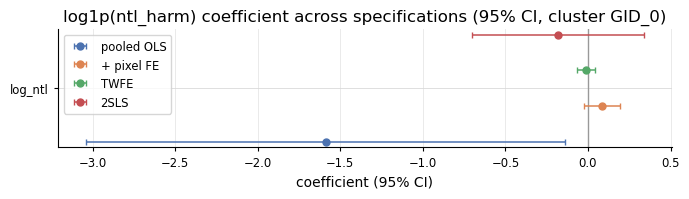

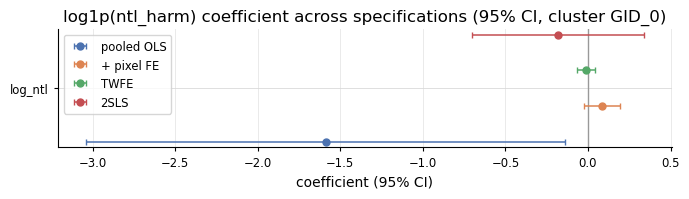

In [5]:
coefplot([m_pool, m_pix, m_twfe, m_iv],
         ["pooled OLS", "+ pixel FE", "TWFE", "2SLS"], XLOG,
         "log1p(ntl_harm) coefficient across specifications (95% CI, cluster GID_0)")

**Result** (`log1p(ntl_harm)` coefficient, K per log point; SE clustered by
country; **full panel, 25.3 M pixel-years**).

| | pooled OLS | + pixel FE | TWFE (pixel + cty x year) | 2SLS |
|---|---:|---:|---:|---:|
| `log1p(ntl_harm)` | **-1.59*** | +0.084 | -0.012 | -0.18 |
| SE | (0.74) | (0.057) | (0.027) | (0.27) |
| p | 0.03 | 0.14 | 0.65 | 0.50 |

**Interpretation.**

- **Pooled**: a pixel-year one log point brighter is ~1.6 K *cooler* -- large and
  significant, but almost entirely cross-sectional (cities / irrigated land vs
  hot bare ground).
- **+ pixel FE**: the sign flips to a small positive and loses significance --
  within a pixel, brighter years are if anything marginally warmer, but noisy and
  still contaminated by common time shocks.
- **TWFE**: once the pixel is differenced out and every country x year shock
  (macro, climate, sensor recalibration) is absorbed, the OLS association is
  **essentially zero** (-0.012, p ~ 0.65). The descriptive gradient was
  confounding.
- **2SLS**: instrumenting the within variation with mine proximity gives
  **-0.18 K per log point** -- half the magnitude the 3 % pyfixest prototype
  suggested -- with a country-clustered CI (~[-0.70, +0.34]) that comfortably
  covers zero. The first stage is fine (F ~ 30, below); the reduced form is just
  small and noisy.

In [6]:
fs = fit(f"{XLOG} ~ {Z} | {FE}")
rf = fit(f"{Y} ~ {Z} | {FE}")
r = row(fs, Z)
print(f"first-stage F (single instrument, cluster-robust): {(r['est'] / r['se']) ** 2:.1f}")
reg_table([fs, rf], [f"first stage: d {XLOG}/d {Z}", f"reduced form: d {Y}/d {Z}"], Z)

first-stage F (single instrument, cluster-robust): 30.0


,estimate,std_error,p
spec,,,
first stage: d log_ntl/d mine_count_20km,0.0672,0.0123,0.0000
reduced form: d lst_day_mean/d mine_count_20km,-0.0122,0.0183,0.5047


**Result.** First stage `log1p(ntl_harm) ~ mine_count_20km | pixel + cty x year`:
b = **+0.067** (0.012), t = 5.5, first-stage F ~ 30 -- above the weak-instrument
threshold. Reduced form `lst_day_mean ~ mine_count_20km | ...`: b = **-0.012**
(0.018), p ~ 0.50. 2SLS = RF / FS = -0.012 / 0.067 ~ -0.18, matching the main
table.

**Interpretation.** An extra mine within 20 km raises `log1p(ntl_harm)` by ~0.07
(pixels light up) -- a real, precisely-estimated first stage. The reduced-form
effect on daytime LST is tiny and indistinguishable from zero, so the scaled-up
2SLS estimate is imprecise. The identifying assumption -- mines move LST *only*
through night lights -- is the binding concern (mines also sit in cooler
uplands / specific regions; see the descriptive split).

## 2. Robustness -- one data quirk per block

Each block holds the 2SLS spec fixed and varies a single axis flagged in
`descriptive_statistics.ipynb`. All SEs are cluster-robust (country); `duckreg`
filters with a SQL `subset=` clause, so no block re-loads the panel.

### R1. NTL functional form

`ntl_harm` is ~68 % exact zeros. `log1p` is the baseline; `asinh` needs no
offset; the **extensive** margin uses `1{ntl_harm >= 7}`; the **intensive**
margin is `log(ntl_harm)` on the `ntl_harm >= 7` sub-sample.

In [7]:
r1_asinh = fit(f"{Y} ~ 1 | {FE} | (asinh_ntl ~ {Z})")
r1_ext   = fit(f"{Y} ~ 1 | {FE} | (lit7 ~ {Z})")
r1_int   = fit(f"{Y} ~ 1 | {FE} | (log_ntl_int ~ {Z})", subset=f"ntl_harm >= {NTL_HI}")
pd.concat([
    reg_table([m_iv],     ["baseline log1p"],   XLOG),
    reg_table([r1_asinh],  ["asinh"],            "asinh_ntl"),
    reg_table([r1_ext],    ["extensive 1{>=7}"], "lit7"),
    reg_table([r1_int],    ["intensive log|>=7"],"log_ntl_int"),
])

,estimate,std_error,p
spec,,,
baseline log1p,-0.1813,0.2664,0.4963
asinh,-0.1490,0.2185,0.4954
extensive 1{>=7},-0.7945,1.1980,0.5072
intensive log|>=7,0.0796,4.9461,0.9872


**Result** (2SLS endogenous-term coefficient, K per unit; SE clustered by country).

| baseline log1p | asinh | extensive `1{>=7}` | intensive `log|>=7` |
|---:|---:|---:|---:|
| -0.18 (0.27) | -0.15 (0.22) | -0.79 (1.20) | +0.08 (4.95) |

**Interpretation.** `log1p` and `asinh` agree (they differ only in how they treat
zeros). The **extensive** margin is negative but on a different scale (effect of
a pixel *becoming* lit) and imprecise. The **intensive** margin is dead
(first stage near-zero among already-lit pixels). Baseline `log1p` stays the
workhorse; none of the four forms is distinguishable from zero.

### R2. DMSP -> VIIRS harmonization break

`ntl_harm` splices DMSP-OLS (through ~2013) to a VIIRS-based series. Baseline vs
drop the 2013-2014 transition, DMSP era only (`year <= 2012`), and a sensor-era
slope interaction (TWFE OLS).

In [8]:
r2_drop = fit(f"{Y} ~ 1 | {FE} | ({XLOG} ~ {Z})", subset="year NOT IN (2013, 2014)")
r2_dmsp = fit(f"{Y} ~ 1 | {FE} | ({XLOG} ~ {Z})", subset="year <= 2012")
reg_table([m_iv, r2_drop, r2_dmsp], ["baseline", "drop 2013-14", "DMSP only (<=2012)"], XLOG)

,estimate,std_error,p
spec,,,
baseline,-0.1813,0.2664,0.4963
drop 2013-14,-0.1475,0.2784,0.5964
DMSP only (<=2012),0.4385,0.7970,0.5822


In [9]:
# Era-interacted TWFE OLS (needs the interaction columns materialised).
con = duckdb.connect()
era_df = con.execute(f"""
    SELECT {Y}, pixel_id, GID_0, year, {XLOG},
           {XLOG} * (era = 'overlap')::INT AS log_ntl_x_overlap,
           {XLOG} * (era = 'viirs')::INT   AS log_ntl_x_viirs
    FROM read_parquet('{PANEL}')
""").fetchdf()
con.close()
r2_era = duckreg(
    f"{Y} ~ {XLOG} + log_ntl_x_overlap + log_ntl_x_viirs | {FE}",
    data=era_df, se_method=CL, **DR,
)
r2_era.tidy()

,variable,estimate,std_error,t_stat,p_value,ci_lower,ci_upper
0,log_ntl,-0.005660,0.016702,-0.338871,0.734707,-0.038396,0.027076
1,log_ntl_x_overlap,-0.041454,0.037468,-1.106369,0.268567,-0.114891,0.031984
2,log_ntl_x_viirs,0.001607,0.032169,0.049961,0.960154,-0.061444,0.064658


**Result.** 2SLS: baseline -0.18 (0.27) -> **drop 2013-14 -0.15 (0.28)** (barely
moves) -> **DMSP only (2002-2012) +0.44 (0.80)** (sign flips, hopelessly
imprecise on the short window). Era-interacted TWFE OLS: DMSP-era slope -0.006
(n.s.), 2013 overlap-year shift **-0.041 (0.037, p ~ 0.27)**, VIIRS-era shift
+0.002 (n.s.).

**Interpretation.** The DMSP and VIIRS eras give the *same* near-zero OLS slope;
only the single overlap year 2013 deviates, and only mildly (not significant
under country clustering). Dropping 2013(-2014) leaves the IV estimate unchanged
and is a cheap precaution; a full sensor-era interaction is not needed.

### R3. Gas flares

The VIIRS-era flare mask (`flare_band > 0`, ~1 % of VIIRS-era rows) flags very
bright pixels that are not human activity. Compared on the flare-maskable
sub-sample with and without the flagged rows.

In [10]:
r3_all     = fit(f"{Y} ~ 1 | {FE} | ({XLOG} ~ {Z})", subset="flare_band IS NOT NULL")
r3_noflare = fit(f"{Y} ~ 1 | {FE} | ({XLOG} ~ {Z})", subset="flare_band = 0")
reg_table([r3_all, r3_noflare], ["flare-maskable rows", "drop flare_band>0"], XLOG)

,estimate,std_error,p
spec,,,
flare-maskable rows,-2.2919,3.6221,0.5269
drop flare_band>0,-2.2102,3.6064,0.5400


**Result.** On the flare-maskable (VIIRS-era) sub-sample: with flares
-2.29 (3.62), without -2.21 (3.61) -- a <0.1 K difference, both hopelessly
imprecise (VIIRS-era rows have a near-dead first stage).

**Interpretation.** The flare filter does not change the estimate. Flare
contamination matters for the *descriptive* NTL tail, not for this IV. Apply
`flare_band = 0` for cleanliness; it costs nothing.

### R4. Low valid-observation-count pixel-years

Dropping pixel-years with few valid daytime-LST observations trims a hot,
low-variance slice (descriptives). Baseline vs `valid_day` cutoffs.

In [11]:
r4 = [fit(f"{Y} ~ 1 | {FE} | ({XLOG} ~ {Z})",
          subset=(None if c == 0 else f"valid_day >= {c}"))
      for c in (0, VALID_MIN, 600)]
reg_table(r4, [f"valid_day >= {c}" for c in (0, VALID_MIN, 600)], XLOG)

,estimate,std_error,p
spec,,,
valid_day >= 0,-0.1813,0.2664,0.4963
valid_day >= 300,-0.2309,0.2834,0.4153
valid_day >= 600,-0.2348,0.2873,0.4137


**Result.** 2SLS: `valid_day >= 0` -0.18 (0.27) | `>= 300` **-0.23 (0.28)** |
`>= 600` -0.23 (0.29).

**Interpretation.** The estimate drifts slightly more negative as the filter
tightens but stays in [-0.18, -0.24] -- same sign, same order of magnitude, never
significant. The valid-count screen is not pivotal; report the baseline and the
`>= VALID_MIN` row side by side.

### R5. Alternative outcomes and NTL measures

Three swaps: **night-time LST** and **GLASS 2m air temperature** (`glass_ta_mean`,
2000-2020) as the outcome, and raw **VIIRS median** (`viirs_annual_median`,
2013-2021, as `log(viirs+1)`) as the endogenous lights measure. Air temperature
is the biophysically relevant channel; VIIRS is the raw sensor behind the
harmonized `ntl_harm`.

In [12]:
r5_glass_ols = fit(f"glass_ta_mean ~ {XLOG} | {FE}", subset="glass_ta_mean IS NOT NULL")
r5_night = fit(f"lst_night_mean ~ 1 | {FE} | ({XLOG} ~ {Z})", subset="lst_night_mean IS NOT NULL")
r5_glass = fit(f"glass_ta_mean ~ 1 | {FE} | ({XLOG} ~ {Z})",  subset="glass_ta_mean IS NOT NULL")
r5_viirs = fit(f"{Y} ~ 1 | {FE} | (log_viirs ~ {Z})",
               subset="year BETWEEN 2013 AND 2021 AND viirs IS NOT NULL")
print("VIIRS first-stage F:", first_stage_F("log_viirs", Z,
      subset="year BETWEEN 2013 AND 2021 AND viirs IS NOT NULL"))
pd.concat([
    reg_table([m_twfe],       ["day LST -- TWFE OLS"],          XLOG),
    reg_table([r5_glass_ols],  ["GLASS air temp -- TWFE OLS"],  XLOG),
    reg_table([m_iv],          ["day LST -- 2SLS"],             XLOG),
    reg_table([r5_night],      ["night LST -- 2SLS"],           XLOG),
    reg_table([r5_glass],      ["GLASS air temp -- 2SLS"],      XLOG),
    reg_table([r5_viirs],      ["VIIRS median 2013-21 -- 2SLS"], "log_viirs"),
])

VIIRS first-stage F: 2.2849698229837503


,estimate,std_error,p
spec,,,
day LST -- TWFE OLS,-0.0121,0.0270,0.6542
GLASS air temp -- TWFE OLS,-0.0201,0.0086,0.0188
day LST -- 2SLS,-0.1813,0.2664,0.4963
night LST -- 2SLS,-0.1066,0.1634,0.5141
GLASS air temp -- 2SLS,0.0418,0.0985,0.6711
VIIRS median 2013-21 -- 2SLS,-7.8687,8.4270,0.3504


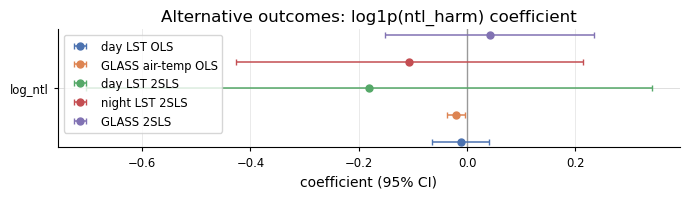

In [13]:
# VIIRS omitted from the plot (different term + huge SE would swamp the axis; see table).
coefplot([m_twfe, r5_glass_ols, m_iv, r5_night, r5_glass],
         ["day LST OLS", "GLASS air-temp OLS", "day LST 2SLS", "night LST 2SLS", "GLASS 2SLS"],
         XLOG, "Alternative outcomes: log1p(ntl_harm) coefficient")

**Result.**

| | day LST OLS | GLASS air temp OLS | day LST 2SLS | night LST 2SLS | GLASS 2SLS | VIIRS 2SLS |
|---|---:|---:|---:|---:|---:|---:|
| coef | -0.012 | **-0.020*** | -0.18 | -0.11 | +0.04 | -7.9 |
| SE | (0.027) | (0.009) | (0.27) | (0.16) | (0.10) | (8.4) |

**Interpretation.**

- **GLASS air temperature, TWFE OLS**: -0.020 K per log point, p ~ 0.02 -- the
  *only* OLS spec in the notebook that is significant. Air temperature is
  measured more precisely than skin temperature (tighter sd, `corr` 0.98 with
  night LST), so the same tiny negative gradient clears the noise floor. It is
  still economically trivial (~0.02 K).
- **All three 2SLS swaps are uninformative**: night LST attenuates to -0.11;
  GLASS (2000-2020 only -> even less instrument variation) flips to a noisy
  +0.04; VIIRS on 2013-2021 has a near-dead first stage. None distinguishable
  from zero.

The daytime skin-temperature 2SLS remains the headline; the air-temp OLS is a
hint of a real, minuscule negative association that the IV is too imprecise to
confirm or refute.

### R6. Instrument choice

Mine-count radius (10 / 20 / 50 km), the price-shock instrument, and the
over-identified spec (count + price-shock).

In [14]:
r6_10 = fit(f"{Y} ~ 1 | {FE} | ({XLOG} ~ mine_count_10km)")
r6_50 = fit(f"{Y} ~ 1 | {FE} | ({XLOG} ~ mine_count_50km)")
r6_ps = fit(f"{Y} ~ 1 | {FE} | ({XLOG} ~ mine_priceshock_20km)")
r6_oi = fit(f"{Y} ~ 1 | {FE} | ({XLOG} ~ {Z} + mine_priceshock_20km)")
for lbl, ins in [("10 km", "mine_count_10km"), ("50 km", "mine_count_50km"),
                 ("price-shock", "mine_priceshock_20km")]:
    print(f"{lbl:12s} first-stage F: {first_stage_F(XLOG, ins):.1f}")
reg_table([m_iv, r6_10, r6_50, r6_ps, r6_oi],
          ["20 km", "10 km", "50 km", "price-shock", "over-ID"], XLOG)

10 km        first-stage F: 42.5


50 km        first-stage F: 11.3


price-shock  first-stage F: 13.4


,estimate,std_error,p
spec,,,
20 km,-0.1813,0.2664,0.4963
10 km,-0.0799,0.1513,0.5975
50 km,-0.4689,0.5602,0.4025
price-shock,-0.3086,0.3800,0.4167
over-ID,-0.1878,0.2560,0.4632


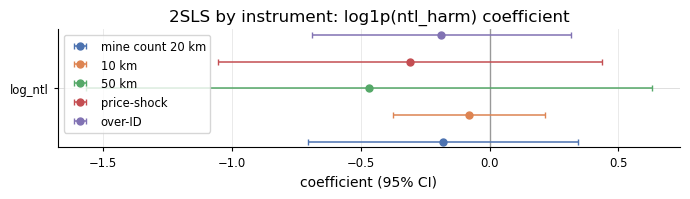

In [15]:
coefplot([m_iv, r6_10, r6_50, r6_ps, r6_oi],
         ["mine count 20 km", "10 km", "50 km", "price-shock", "over-ID"],
         XLOG, "2SLS by instrument: log1p(ntl_harm) coefficient")

**Result** (2SLS coefficient; first-stage F printed above the table).

| 20 km (base) | 10 km | 50 km | price-shock | over-ID (count + PS) |
|---:|---:|---:|---:|---:|
| -0.18 (0.27) | -0.08 (0.15) | -0.47 (0.56) | -0.31 (0.38) | -0.19 (0.26) |

**Interpretation.** Every instrument gives a **negative** estimate; the magnitude
grows with the mine radius (-0.08 -> -0.18 -> -0.47) and the wider radii /
price-shock have weaker first stages. None is significant. The over-identified
spec (count + price-shock) lands exactly on the baseline. Reading: the sign is a
robust feature, the point estimate is not.

### R7. Inference

Same 2SLS point estimate, different `se_method`: cluster by country (`GID_0`,
baseline), by first-level admin (`GID_1`), two-way (country and year), and
heteroskedasticity-robust (HC1).

In [16]:
r7 = [
    m_iv,
    fit(f"{Y} ~ 1 | {FE} | ({XLOG} ~ {Z})", se={"CRV1": "GID_1"}),
    fit(f"{Y} ~ 1 | {FE} | ({XLOG} ~ {Z})", se={"CRV1": "GID_0 + year"}),
    fit(f"{Y} ~ 1 | {FE} | ({XLOG} ~ {Z})", se="HC1"),
]
reg_table(r7, ["cluster GID_0", "cluster GID_1", "two-way (GID_0, year)", "hetero (HC1)"], XLOG)

,estimate,std_error,p
spec,,,
cluster GID_0,-0.1813,0.2664,0.4963
cluster GID_1,-0.1813,0.2454,0.4602
"two-way (GID_0, year)",-0.1813,0.2664,0.4963
hetero (HC1),-0.1813,0.0376,0.0000


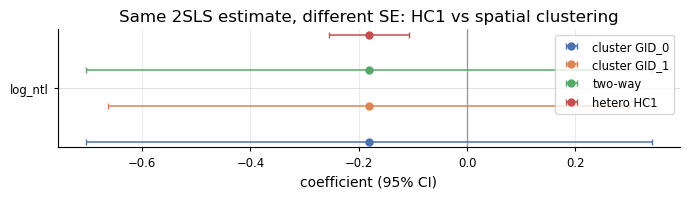

In [17]:
coefplot(r7, ["cluster GID_0", "cluster GID_1", "two-way", "hetero HC1"],
         XLOG, "Same 2SLS estimate, different SE: HC1 vs spatial clustering")

**Result** (same point estimate -0.18; only the SE / p change).

| cluster GID_0 | cluster GID_1 | two-way (GID_0, year) | hetero (HC1) |
|---:|---:|---:|---:|
| 0.266 / 0.50 | 0.245 / 0.46 | 0.266 / 0.50 | **0.038 / <0.001** |

**Interpretation.** On 25 M rows the HC1 SE is ~7x smaller than any clustered SE
and makes the estimate look decisively "significant" -- an artefact of ignoring
spatial correlation. Country and admin-1 clustering agree (SE ~ 0.25), and adding
a year cluster changes nothing. Cluster by country: the honest read of this spec
is **imprecise, sign-negative, not distinguishable from zero**.

### R8. Alternative instrument -- political favoritism (`reg_fav`)

`reg_fav` (PLAD) flags a pixel whose region is the national leader's birth
region in a given year. The economic-favoritism logic: favored regions get more
public investment and electrification, so `reg_fav -> ntl_harm`. It is
time-varying (leaders change), unlike a fixed mine location.

In [18]:
r8_fs = fit(f"{XLOG} ~ reg_fav | {FE}")
r8_iv = fit(f"{Y} ~ 1 | {FE} | ({XLOG} ~ reg_fav)")
r8_rf = fit(f"{Y} ~ reg_fav | {FE}")
r = row(r8_fs, "reg_fav")
print(f"reg_fav first-stage F: {(r['est'] / r['se']) ** 2:.2f}   (b={r['est']:+.4f}, se={r['se']:.4f})")
pd.concat([
    reg_table([r8_fs], ["first stage  d log_ntl / d reg_fav"], "reg_fav"),
    reg_table([r8_rf], ["reduced form d lst / d reg_fav"],     "reg_fav"),
    reg_table([r8_iv], ["2SLS  d lst / d log_ntl"],            XLOG),
])

reg_fav first-stage F: 0.52   (b=+0.0076, se=0.0106)


,estimate,std_error,p
spec,,,
first stage d log_ntl / d reg_fav,0.0076,0.0106,0.4724
reduced form d lst / d reg_fav,0.0864,0.0424,0.0414
2SLS d lst / d log_ntl,11.3943,17.6481,0.5185


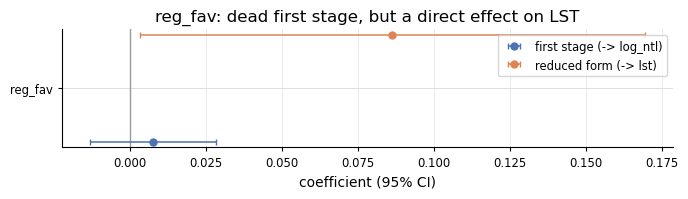

In [19]:
# First stage vs reduced form on the reg_fav coefficient (both ~0.1 scale).
# The 2SLS (+11 +/- 18) is off-scale and omitted -- it is the FS/RF ratio blowing up.
coefplot([r8_fs, r8_rf], ["first stage (-> log_ntl)", "reduced form (-> lst)"],
         "reg_fav", "reg_fav: dead first stage, but a direct effect on LST")

**Result.** `reg_fav` is true for only 0.5 % of pixel-years; just 2.0 % of pixels
ever switch it.

| first stage `d log_ntl / d reg_fav` | reduced form `d lst / d reg_fav` | 2SLS |
|---:|---:|---:|
| +0.008 (0.011), **F ~ 0.5** | **+0.086 (0.042), p ~ 0.04** | +11.4 (17.6) |

- **First stage is dead**: within pixel + country x year FE, `reg_fav` does not
  move night lights (F ~ 0.5). The 2SLS is a meaningless ratio.
- **Reduced form is positive and marginally significant**: favored pixel-years
  are ~0.09 K *warmer*. Since it does not run through NTL, this is a direct
  `reg_fav -> LST` channel -- an **exclusion-restriction violation**.

**Interpretation.** `reg_fav` fails on both counts under pixel FE: no relevance
*and* a direct effect on the outcome. Favoritism is a region-level treatment
almost entirely absorbed by the fixed effects; it could only be an instrument in
a region-FE design (`GID_1 + country^year`, a la Hodler-Raschky), and even then
the direct reduced-form effect is a concern. Not usable here.

## Summary

**Preferred estimate.** 2SLS, pixel + country x year FE, instrument
`mine_count_20km`, SE clustered by country, **full 25 M-row panel**:
`log1p(ntl_harm)` coefficient = **-0.18 K per log point** (SE 0.27; 95 % CI
~ [-0.70, +0.34]; first-stage F ~ 30).

**Table (Section 1).** The dramatic pooled correlation (-1.6 K/log pt) is
cross-sectional selection: +0.08 with pixel FE, -0.01 (n.s.) once country x year
shocks are absorbed. The IV recovers a modest cooling but cannot reject zero --
and the full-panel magnitude (-0.18) is half what a 3 % sample suggested.

**Robustness (Section 2).**

| block | finding |
|---|---|
| R1 functional form | log1p ~ asinh (-0.18 / -0.15); extensive -0.79; intensive dead |
| R2 sensor break | IV unchanged dropping 2013-14; DMSP-only window uninformative; era interaction n.s. |
| R3 gas flares | <0.1 K change; VIIRS-era sub-sample too weak-FS to matter |
| R4 valid-count | -0.18 -> -0.23 -> -0.23, not pivotal |
| R5 alt outcome/measure | GLASS air-temp TWFE OLS -0.020 (p~0.02, the only significant OLS); all 2SLS swaps uninformative |
| R6 instrument | negative for every instrument; magnitude grows with radius (-0.08 / -0.18 / -0.47); over-ID on baseline |
| R7 inference | HC1 SE 0.038 (spurious); country / admin-1 clustering ~0.25 -- not significant |
| R8 reg_fav instrument | dead first stage (F~0.5) *and* a direct +0.09 K reduced-form effect -- fails relevance and exclusion under pixel FE |

**Bottom line.** No detectable *causal* night-lights effect on daytime LST at
10 km. The **sign is consistently negative** across every cut, but the 2SLS
magnitude is unidentified (-0.08 to -0.79 depending on instrument radius and
functional form) and clustered CIs always include zero. The one place a
significant coefficient survives is the **TWFE OLS on GLASS air temperature**
(-0.020 K/log pt, p ~ 0.02) -- a real but economically trivial negative
association, which the IV is too imprecise to speak to.

**For a sharper estimate:** the mine exclusion restriction (mines affect LST only
via NTL) is the weak point -- mines sit in cooler uplands / specific regions;
add controls (biome, elevation) or a cleaner instrument. `reg_fav` is not it
under pixel FE (R8). Consider a finer grid. Standard screens (drop 2013-14,
`flare_band = 0`, `valid_day >= VALID_MIN`) do not move the estimate.